In [1]:
import numpy as np
import glob
import os

import matplotlib.pyplot as plt

from scripts_fermions.operators import Hamiltonian, Boost
from scripts_fermions.construct_P_state import construct_P_state

import yastn
from yastn.tn import mps

In [2]:
g = 1
v, Q = 1, 1
N = 256
a = 0.125
m = 0.5
#
glob_path = os.path.join(os.path.abspath(""), "./results_fermions/g=1.0000/**/state_t=*.npy")
fnames = glob.glob(glob_path, recursive=True)
fns = sorted([fname for fname in fnames if all(x in fname for x in ["/g=1.0000/", "dt=0.0625", f"{N=}", f"{v=:0.4f}", f"{Q=:0.4f}", f"{a=:0.4f}", f"{m=:0.4f}"])]);

In [8]:
#
D = 128
ops = yastn.operators.SpinlessFermions(sym='U1', tensordot_policy='no_fusion')
#
glob_path = os.path.join(os.path.abspath(""), "./results_fermions/g=1.0000/**/gs/**/state_D=*.npy")
fnames = glob.glob(glob_path, recursive=True)
fgs = sorted([fname for fname in fnames if all(x in fname for x in ["/g=1.0000/", f"{N=}", f"{a=:0.4f}", f"{D=}", f"{m=:0.4f}"])])
#
def fn_mass(fns, **kwargs):
    return [x for x in fns if all( f"{k}={v}" in x for k, v in kwargs.items())][0]
#
d_gs = np.load(fn_mass(fgs ), allow_pickle=True).item()


In [9]:
d_gs = np.load(fn_mass(fgs, m=m), allow_pickle=True).item()
psi_gs = yastn.from_dict(d_gs['psi'])

H = Hamiltonian(N, m, g, t=0, a=a, v=1, Q=0, ops=ops)
K = Boost(N, m, g, a, ops)
E_gs = mps.vdot(psi_gs, H, psi_gs).real

In [3]:
ts = np.linspace(0, N * a / 2, 17)
Ds = [128, 256]
PPs = np.linspace(0, 3, 25)

In [11]:
psi_t = {(t, D): yastn.from_dict(np.load(fn_mass(fns, t=t, D=D), allow_pickle=True).item()['psi']) for t in ts for D in Ds}


In [ ]:
psi_P = {}
eng_P = {}
for PP in PPs:
    print(PP)
    psi_P[PP], eng_P[PP] = construct_P_state(PP, N, m, g, a, psi_gs, ops)

0.0
0.125
0.25
0.375
0.5
0.625
0.75
0.875
1.0
1.125
1.25
1.375
1.5
1.625
1.75
1.875
2.0
2.125
2.25
2.375
2.5
2.625
2.75
2.875
3.0


In [7]:
probs_R = {}
for (t, D), pt in psi_t.items():
    for PP, pc in psi_P.items():
        if (t, D, PP) not in probs_R:
            probs_R[t, D, PP] = np.abs(mps.vdot(pt, pc)) ** 2


In [4]:
#np.save(f"./results_fermions/probs_R_{m=}_{N=}_{a=}.npy", probs_R, allow_pickle=True)
probs_R = np.load(f"./results_fermions/probs_R_{m=}_{N=}_{a=}.npy", allow_pickle=True).item()

In [12]:
probs_gs = {(t, D): np.abs(mps.vdot(pt, psi_gs)) ** 2 for (t, D), pt in psi_t.items()}

In [5]:
#np.save(f"./results_fermions/probs_gs_{m=}_{N=}_{a=}.npy", probs_gs, allow_pickle=True)
probs_gs = np.load(f"./results_fermions/probs_gs_{m=}_{N=}_{a=}.npy", allow_pickle=True).item()


Text(0.5, 1.0, 'N=256  a=0.125')

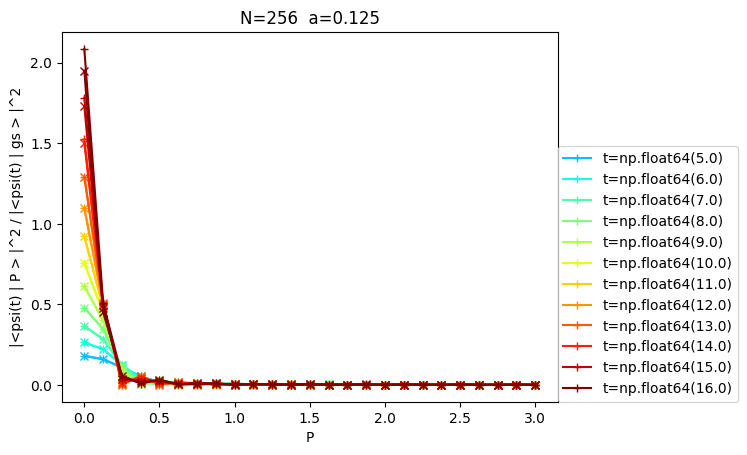

In [7]:
cm = plt.cm.jet
syms = dict(zip(Ds, ['+-', 'x-', 'o-']))
for t in ts[5:]:
  for D in Ds:
    pr = [probs_R[t, D, PP] / probs_gs[t, D] for PP in PPs]
    line, = plt.plot(PPs, pr, syms[D], color = cm(t / ts[-1]))
    if D == Ds[0]:
      line.set_label(f"{t=}")

plt.xlabel('P')
plt.ylabel("|<psi(t) | P > |^2 / |<psi(t) | gs > |^2")
plt.legend(loc=(1, 0))
#plt.xlim([0, 1])
plt.title(f"{N=}  {a=}")
#plt.ylim([1e-4, 1e2])

Text(0.5, 1.0, 'N=256  a=0.125')

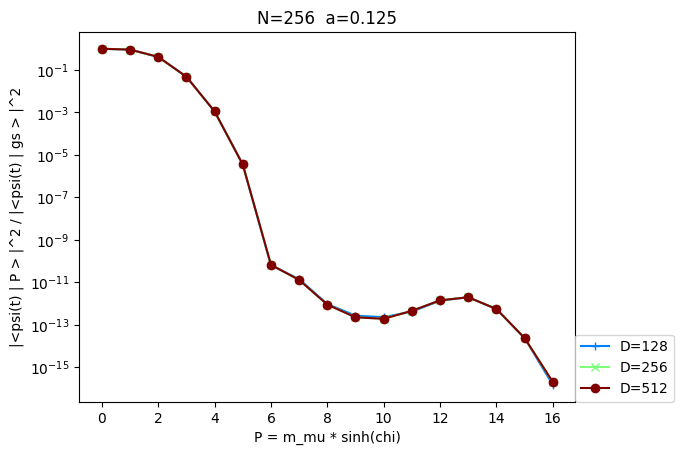

In [22]:
cm = plt.cm.jet
syms = dict(zip(Ds, ['+-', 'x-', 'o-']))
for D in Ds:
    pr = [probs_gs[t, D] for t in ts]
    line, = plt.semilogy(ts, pr, syms[D], color = cm(D / Ds[-1]))
    line.set_label(f"{D=}")

plt.xlabel('P = m_mu * sinh(chi)')
plt.ylabel("|<psi(t) | P > |^2 / |<psi(t) | gs > |^2")
plt.legend(loc=(1, 0))
plt.title(f"{N=}  {a=}")
#plt.ylim([1e-4, 1e2])

In [67]:
def trace_norm(psi0, psi1, Nc = 64):
    N = psi0.N
    N2 = N // 2
    s0 = N2 - Nc // 2
    s1 = N2 + Nc // 2


    psi0 = psi0.shallow_copy()
    psi1 = psi1.shallow_copy()

    for n in range(0, N2):
        psi0.orthogonalize_site_(n=n, to='last', normalize=True)
        psi0.absorb_central_(to='last')
        psi1.orthogonalize_site_(n=n, to='last', normalize=True)
        psi1.absorb_central_(to='last')

    for n in range(N-1, N2, -1):
        psi0.orthogonalize_site_(n=n, to='first', normalize=True)
        psi0.absorb_central_(to='first')
        psi1.orthogonalize_site_(n=n, to='first', normalize=True)
        psi1.absorb_central_(to='first')

    tmp = yastn.ncon([psi0[s0], psi1[s0].conj()], [[-0, 1, -2], [-1, 1, -3]])
    for n in range(s0+1, s1):
        tmp = yastn.ncon([tmp, psi0[n], psi1[n].conj()], [[-0, -1, 1, 3], [1, 2, -2], [3, 2, -3]])
    return np.abs(yastn.vdot(tmp, tmp).item())


In [68]:
x = trace_norm(psi_t[10], psi_chi[0], Nc = 32)